In [1]:
#Decision Tree Example
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
#1. Load Dataset
df= pd.read_csv("email_spam_dataset.csv")

In [3]:
#2. Define features and targets
X= df.drop("Spam", axis =1)
y= df["Spam"]

In [4]:
# 3. Train - Test Split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
#4.Train Decision tree (Entropy)
model = DecisionTreeClassifier(criterion="entropy",random_state=42, max_depth =4)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [7]:
#5. Pridctions & Evaluation 
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

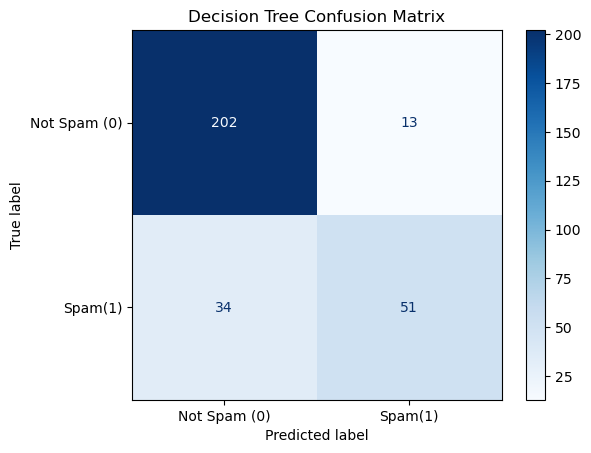

In [8]:
ConfusionMatrixDisplay(cm, display_labels=["Not Spam (0)","Spam(1)"]).plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [9]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       215
           1       0.80      0.60      0.68        85

    accuracy                           0.84       300
   macro avg       0.83      0.77      0.79       300
weighted avg       0.84      0.84      0.84       300



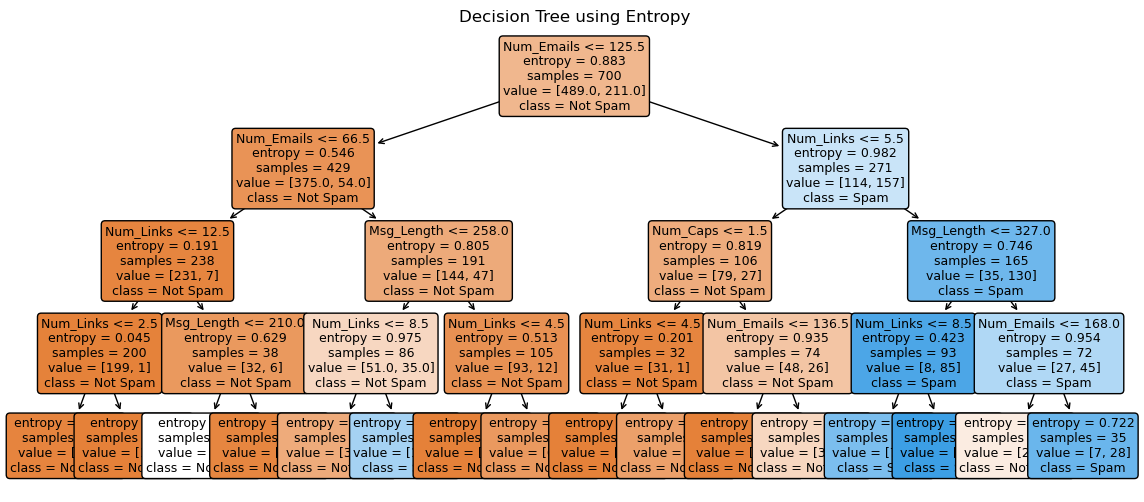

In [11]:
#6. Visualize the Tree 
plt.figure(figsize =(14,6))
plot_tree(model,
          feature_names=X.columns,
          class_names=["Not Spam", "Spam"],
          filled=True,
          rounded=True,
          fontsize = 9)
plt.title("Decision Tree using Entropy")
plt.show()
    

In [12]:
#7.Print the actual decision rules
tree_rules =export_text(model, feature_names=list(X.columns))
print("\nDecision Tree Rules:\n")
print(tree_rules)


Decision Tree Rules:

|--- Num_Emails <= 125.50
|   |--- Num_Emails <= 66.50
|   |   |--- Num_Links <= 12.50
|   |   |   |--- Num_Links <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- Num_Links >  2.50
|   |   |   |   |--- class: 0
|   |   |--- Num_Links >  12.50
|   |   |   |--- Msg_Length <= 210.00
|   |   |   |   |--- class: 0
|   |   |   |--- Msg_Length >  210.00
|   |   |   |   |--- class: 0
|   |--- Num_Emails >  66.50
|   |   |--- Msg_Length <= 258.00
|   |   |   |--- Num_Links <= 8.50
|   |   |   |   |--- class: 0
|   |   |   |--- Num_Links >  8.50
|   |   |   |   |--- class: 1
|   |   |--- Msg_Length >  258.00
|   |   |   |--- Num_Links <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- Num_Links >  4.50
|   |   |   |   |--- class: 0
|--- Num_Emails >  125.50
|   |--- Num_Links <= 5.50
|   |   |--- Num_Caps <= 1.50
|   |   |   |--- Num_Links <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- Num_Links >  4.50
|   |   |   |   |--- class: 0
|   |   |--- Num_Caps 

In [13]:
#What if we use gini impurity?
models={
    "Entropy": DecisionTreeClassifier(criterion="entropy",max_depth=4, random_state=42),
    "Gini":DecisionTreeClassifier(criterion="gini",max_depth=4, random_state=42)
}

In [15]:
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"\n=== {name} Tree Accuracy ===")
    print(classification_report(y_test, pred))
    


=== Entropy Tree Accuracy ===
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       215
           1       0.80      0.60      0.68        85

    accuracy                           0.84       300
   macro avg       0.83      0.77      0.79       300
weighted avg       0.84      0.84      0.84       300


=== Gini Tree Accuracy ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       215
           1       0.83      0.64      0.72        85

    accuracy                           0.86       300
   macro avg       0.85      0.79      0.81       300
weighted avg       0.86      0.86      0.85       300



In [16]:
#What if we use different max_depth values? (underfitting versus overfitting)

In [18]:
for d in [2, 3, 4, 6, None]:
    model = DecisionTreeClassifier(max_depth=d, random_state = 42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"Max Depth={d}, Test Accuracy={acc:.3f}")
                     
                                  
    

Max Depth=2, Test Accuracy=0.823
Max Depth=3, Test Accuracy=0.823
Max Depth=4, Test Accuracy=0.860
Max Depth=6, Test Accuracy=0.837
Max Depth=None, Test Accuracy=0.820


In [20]:
#K fold cross validation for possibly more accuracy
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,X,y,cv=5)
print("Cross validation accuracy:",scores)
print("Average:", scores.mean())

Cross validation accuracy: [0.805 0.795 0.775 0.795 0.805]
Average: 0.795
